In [ ]:
import pandas as pd, numpy as np

In [ ]:
data=pd.read_csv('/content/IPL_Matches_2008_2022.csv')
data.head()

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough
3,1312197,Kolkata,2022-05-24,2022,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,N,Gujarat Titans,Wickets,7.0,NaN,DA Miller,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",BNJ Oxenford,VK Sharma
4,1304116,Mumbai,2022-05-22,2022,70,Sunrisers Hyderabad,Punjab Kings,"Wankhede Stadium, Mumbai",Sunrisers Hyderabad,bat,N,Punjab Kings,Wickets,5.0,NaN,Harpreet Brar,"['PK Garg', 'Abhishek Sharma', 'RA Tripathi', ...","['JM Bairstow', 'S Dhawan', 'M Shahrukh Khan',...",AK Chaudhary,NA Patwardhan


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               950 non-null    int64  
 1   City             899 non-null    object 
 2   Date             950 non-null    object 
 3   Season           950 non-null    object 
 4   MatchNumber      950 non-null    object 
 5   Team1            950 non-null    object 
 6   Team2            950 non-null    object 
 7   Venue            950 non-null    object 
 8   TossWinner       950 non-null    object 
 9   TossDecision     950 non-null    object 
 10  SuperOver        946 non-null    object 
 11  WinningTeam      946 non-null    object 
 12  WonBy            950 non-null    object 
 13  Margin           932 non-null    float64
 14  method           19 non-null     object 
 15  Player_of_Match  946 non-null    object 
 16  Team1Players     950 non-null    object 
 17  Team2Players    

In [ ]:
data.shape

(950, 20)

In [ ]:
data['Margin'].mean()

17.0568669527897

In [ ]:
data['Margin'].mode()[0]

6.0

In [ ]:
data['Margin'].median()

8.0

In [ ]:
data['City'].mode()[0]

'Mumbai'

In [ ]:
data.City.value_counts()

,count
City,
Mumbai,159
Kolkata,79
Delhi,78
Chennai,67
Bangalore,65
Hyderabad,64
Chandigarh,56
Pune,51
Jaipur,47


In [ ]:
data['Margin'].var()

467.9913921068758

In [ ]:
data['Margin'].std()

21.6331087018689

<Axes: ylabel='Margin'>

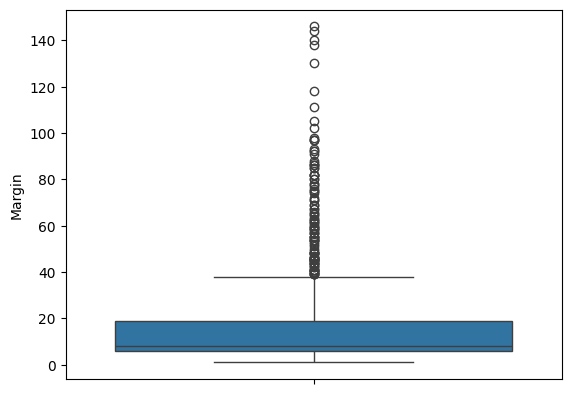

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(data['Margin'])

In [ ]:
data['Margin'].isna().sum()

18

In [ ]:
#outliers

q1=data['Margin'].quantile(0.25)
q2=data['Margin'].quantile(0.50)
q3=data['Margin'].quantile(0.75)

IQR=q3-q1

lower_bound=q1-(1.5*IQR)
upper_bound=q3+(1.5*IQR)

outliers=data[(data['Margin'] > upper_bound) | (data['Margin'] < lower_bound)]
outliers
print(len(outliers))

114


In [ ]:
data_without_outliers=data[(data['Margin'] > lower_bound) & (data['Margin'] <= upper_bound)]
print(len(data_without_outliers) )
print(data_without_outliers.shape)
data_without_outliers

818
(818, 20)


,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough
3,1312197,Kolkata,2022-05-24,2022,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,N,Gujarat Titans,Wickets,7.0,NaN,DA Miller,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",BNJ Oxenford,VK Sharma
4,1304116,Mumbai,2022-05-22,2022,70,Sunrisers Hyderabad,Punjab Kings,"Wankhede Stadium, Mumbai",Sunrisers Hyderabad,bat,N,Punjab Kings,Wickets,5.0,NaN,Harpreet Brar,"['PK Garg', 'Abhishek Sharma', 'RA Tripathi', ...","['JM Bairstow', 'S Dhawan', 'M Shahrukh Khan',...",AK Chaudhary,NA Patwardhan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
944,335987,Jaipur,2008-04-21,2007/08,6,Rajasthan Royals,Kings XI Punjab,Sawai Mansingh Stadium,Kings XI Punjab,bat,N,Rajasthan Royals,Wickets,6.0,NaN,SR Watson,"['M Kaif', 'Kamran Akmal', 'YK Pathan', 'SR Wa...","['K Goel', 'JR Hopes', 'KC Sangakkara', 'DPMD ...",Aleem Dar,RB Tiffin
945,335986,Kolkata,2008-04-20,2007/08,4,Kolkata Knight Riders,Deccan Chargers,Eden Gardens,Deccan Chargers,bat,N,Kolkata Knight Riders,Wickets,5.0,NaN,DJ Hussey,"['WP Saha', 'BB McCullum', 'RT Ponting', 'SC G...","['AC Gilchrist', 'Y Venugopal Rao', 'VVS Laxma...",BF Bowden,K Hariharan
946,335985,Mumbai,2008-04-20,2007/08,5,Mumbai Indians,Royal Challengers Bangalore,Wankhede Stadium,Mumbai Indians,bat,N,Royal Challengers Bangalore,Wickets,5.0,NaN,MV Boucher,"['L Ronchi', 'ST Jayasuriya', 'DJ Thornely', '...","['S Chanderpaul', 'R Dravid', 'LRPL Taylor', '...",SJ Davis,DJ Harper
947,335984,Delhi,2008-04-19,2007/08,3,Delhi Daredevils,Rajasthan Royals,Feroz Shah Kotla,Rajasthan Royals,bat,N,Delhi Daredevils,Wickets,9.0,NaN,MF Maharoof,"['G Gambhir', 'V Sehwag', 'S Dhawan', 'MK Tiwa...","['T Kohli', 'YK Pathan', 'SR Watson', 'M Kaif'...",Aleem Dar,GA Pratapkumar


In [ ]:
#data capping

#data capping

# Method 2: Cap outliers (replace with the boundary values)
import copy

#df = copy.deepcopy(data)
df=copy.deepcopy(data)

df.loc[df['Margin'] > upper_bound] = upper_bound
df.loc[df['Margin'] < lower_bound] = lower_bound

df.shape


<ipython-input-52-c7b0460d35ca>:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '38.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['Margin'] > upper_bound] = upper_bound


(950, 20)

In [ ]:
# prompt: find the outliers in Margin column and how to cap or remove outliers

# Calculate the boundaries for outlier detection
q1 = data['Margin'].quantile(0.25)
q3 = data['Margin'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identify outliers
outliers = data[(data['Margin'] < lower_bound) | (data['Margin'] > upper_bound)]

# Method 1: Remove outliers
data_no_outliers = data[(data['Margin'] >= lower_bound) & (data['Margin'] <= upper_bound)]

# Method 2: Cap outliers (replace with the boundary values)
data_capped = data.copy()
data_capped.loc[data_capped['Margin'] < lower_bound, 'Margin'] = lower_bound
data_capped.loc[data_capped['Margin'] > upper_bound, 'Margin'] = upper_bound

# Now you have two options:
# 1. data_no_outliers: DataFrame without the outliers
# 2. data_capped: DataFrame with capped outlier values

print("Number of outliers:", len(outliers))
print("Original DataFrame shape:", data.shape)
print("DataFrame with outliers removed:", data_no_outliers.shape)
print("DataFrame with capped outliers:", data_capped.shape)


Number of outliers: 114
Original DataFrame shape: (950, 20)
DataFrame with outliers removed: (818, 20)
DataFrame with capped outliers: (950, 20)


In [ ]:
#by using z_score

df2=copy.deepcopy(data)

df2['zscore']=(df2.Margin -df2.Margin.mean())/df2.Margin.std()

#zscores=df2[(df2['Margin'] > 3)  & (df2['Margin'] < -3)]

# Method 1: Remove outliers
df_no_outliers_zscore = df2[(df2['zscore'] <= 3) & (df2['zscore'] >= -3)]


df_no_outliers_zscore.shape

(904, 21)

In [ ]:
# prompt: #by using z_score for Margin

# Calculate z-scores for 'Margin'
df2['zscore'] = (df2['Margin'] - df2['Margin'].mean()) / df2['Margin'].std()

# Identify outliers based on z-score threshold (e.g., |zscore| > 3)
outliers_zscore = df2[(df2['zscore'] > 3) | (df2['zscore'] < -3)]

# Remove outliers or cap them
# Method 1: Remove outliers
df_no_outliers_zscore = df2[(df2['zscore'] <= 3) & (df2['zscore'] >= -3)]

# Method 2: Cap outliers (replace with the boundary values based on z-score)
df_capped_zscore = df2.copy()
upper_zscore_bound = df2['Margin'].mean() + 3 * df2['Margin'].std()
lower_zscore_bound = df2['Margin'].mean() - 3 * df2['Margin'].std()

df_capped_zscore.loc[df_capped_zscore['Margin'] > upper_zscore_bound, 'Margin'] = upper_zscore_bound
df_capped_zscore.loc[df_capped_zscore['Margin'] < lower_zscore_bound, 'Margin'] = lower_zscore_bound

# Print results
print("Number of outliers (z-score):", len(outliers_zscore))
print("Original DataFrame shape:", df2.shape)
print("DataFrame with outliers removed (z-score):", df_no_outliers_zscore.shape)
print("DataFrame with capped outliers (z-score):", df_capped_zscore.shape)
